In [1]:
import csv
import math
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
import sklearn
import sys
import statsmodels.api as sm
import statsmodels.formula.api as smf
import warnings
from scipy.stats import mannwhitneyu
from pingouin import ancova
#from pingouin import ancova
#import pingouin as pg
from datetime import datetime, timedelta,date
warnings.filterwarnings('ignore')
from IPython.display import HTML
import seaborn as sns
from scipy.stats import mannwhitneyu
import scipy.stats as stats
import matplotlib.pyplot as plt

# These are used for the chi-squared test and post hoc testing
from scipy.stats import chi2_contingency
from itertools import combinations
from scipy.stats import fisher_exact



# Deactivate Jedi so that autocomplete is faster
%config Completer.use_jedi = False
pd.options.display.max_columns = 40
pd.options.display.min_rows = 100

In [2]:
# File updated on Oct 2 2023 in order to deal with erroneous zeroes in the cbc data
subjects = pd.read_csv("data/aim2_exwas_data_2024-June-11.csv")

# Figures for ExWAS paper

- Associations between prenatal daily hand sanitizer and 5-year asthma after controlling for other prenatal hand sanitizer use at other time points, as well as the other covariates

- Associations between chemical hand cleaner and 5-year asthma after controlling for other chemical hand cleaner use at other time points, as well as the other covariates

In [3]:
from matplotlib.ticker import FuncFormatter

# Create a function to format the tick labels with decimal notation
def log_fmt(x, pos):
    if x >= 1:
        return f"{x:.1f}"
    else:
        return f"{x:.1e}"

# Supplementary Figure 6b: ii. Weekly chemical hand cleaner use during pregnancy and association with asthma at 5 years after controlling for it's postnatal use

In [4]:
alternatedf = subjects.copy()
outcome = "asthma_5y"
visit = "5 Years"

odds_ratio_table = pd.DataFrame(columns=['time outcome assessed','outcome','exposure','total children','total cases','total exposures','total cases with exposure','OR','Lower CI', 'Upper CI','P-value'])

alternatedf = alternatedf[~alternatedf['weekly_chem_hand_cleaner_use_mother_prenatal'].isna()]
alternatedf = alternatedf[~alternatedf[outcome].isna()]
total_cases = alternatedf[alternatedf[outcome]==1]
total_cases_exposed = total_cases[total_cases["weekly_chem_hand_cleaner_use_mother_prenatal"]==1]
total_exposures = alternatedf[alternatedf["weekly_chem_hand_cleaner_use_mother_prenatal"]==1]
# Fit ANCOVA model with interaction term
model = sm.formula.logit('asthma_5y ~ weekly_chem_hand_cleaner_use_mother_prenatal + is_male + site_toronto + site_edmonton + site_vancouver + EBF_6m + vaginal_birth + total_household_income_PR18WK + older_children_in_home_3m + is_caucasian + num_antibiotic_courses_birth_to_1y + family_asthma_history + frequency_of_use_of_chemical_hand_cleaner_3m + frequency_of_use_of_chemical_hand_cleaner_1y', data=alternatedf).fit()

# Print model summary
print(model.summary())

odds_ratios = pd.DataFrame(
    {
        "OR": model.params,
        "Lower CI": model.conf_int()[0],
        "Upper CI": model.conf_int()[1]
    }
)
odds_ratios = np.exp(odds_ratios)

odds_ratios['P-value'] = round(model.pvalues,4)
odds_ratios[odds_ratios['P-value']<0.05]
odds_ratios['outcome']=outcome
odds_ratios['Lower CI'] = round(odds_ratios['Lower CI'],2)
odds_ratios['Upper CI'] = round(odds_ratios['Upper CI'],2)
odds_ratios['OR'] = round(odds_ratios['OR'],2)


odds_ratios = odds_ratios.loc["weekly_chem_hand_cleaner_use_mother_prenatal"]    


significant_effect_row = odds_ratios.to_dict()
                        
significant_effect_row['exposure']="Weekly chemical hand cleaner\n use by mother(prenatal)"
significant_effect_row['time outcome assessed']="5 years"
significant_effect_row['total cases']=len(total_cases)
significant_effect_row['total exposures']=len(total_exposures)
significant_effect_row['total cases with exposure']=len(total_cases_exposed)
significant_effect_row['total children']=len(alternatedf)


odds_ratio_table.loc[len(odds_ratio_table)] = significant_effect_row

Optimization terminated successfully.
         Current function value: 0.235882
         Iterations 7
                           Logit Regression Results                           
Dep. Variable:              asthma_5y   No. Observations:                 1853
Model:                          Logit   Df Residuals:                     1838
Method:                           MLE   Df Model:                           14
Date:                Fri, 21 Nov 2025   Pseudo R-squ.:                 0.08154
Time:                        14:04:13   Log-Likelihood:                -437.09
converged:                       True   LL-Null:                       -475.89
Covariance Type:            nonrobust   LLR p-value:                 7.824e-11
                                                   coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------------------------
Intercept                               

In [5]:
odds_ratio_table

,time outcome assessed,outcome,exposure,total children,total cases,total exposures,total cases with exposure,OR,Lower CI,Upper CI,P-value
0,5 years,asthma_5y,Weekly chemical hand cleaner\n use by mother(p...,2295,156,64,17,4.82,2.16,10.72,0.0001


In [6]:
alternatedf = subjects.copy()
outcome = "asthma_5y"
visit = "5 Years"

odds_ratio_table = pd.DataFrame(columns=['time outcome assessed','outcome','exposure','total children','total cases','total exposures','total cases with exposure','OR','Lower CI', 'Upper CI','P-value'])

alternatedf = alternatedf[~alternatedf['weekly_chem_hand_cleaner_use_mother_prenatal'].isna()]
alternatedf = alternatedf[~alternatedf[outcome].isna()]
total_cases = alternatedf[alternatedf[outcome]==1]
total_cases_exposed = total_cases[total_cases["weekly_chem_hand_cleaner_use_mother_prenatal"]==1]
total_exposures = alternatedf[alternatedf["weekly_chem_hand_cleaner_use_mother_prenatal"]==1]
# Fit ANCOVA model with interaction term
model = sm.formula.logit('asthma_5y ~ weekly_chem_hand_cleaner_use_mother_prenatal + is_male + site_toronto + site_edmonton + site_vancouver + EBF_6m + vaginal_birth + total_household_income_PR18WK + older_children_in_home_3m + is_caucasian + num_antibiotic_courses_birth_to_1y + family_asthma_history + frequency_of_use_of_chemical_hand_cleaner_3m + frequency_of_use_of_chemical_hand_cleaner_1y', data=alternatedf).fit()

# Print model summary
print(model.summary())

odds_ratios = pd.DataFrame(
    {
        "OR": model.params,
        "Lower CI": model.conf_int()[0],
        "Upper CI": model.conf_int()[1]
    }
)
odds_ratios = np.exp(odds_ratios)

odds_ratios['P-value'] = round(model.pvalues,4)
odds_ratios[odds_ratios['P-value']<0.05]
odds_ratios['outcome']=outcome
odds_ratios['Lower CI'] = round(odds_ratios['Lower CI'],2)
odds_ratios['Upper CI'] = round(odds_ratios['Upper CI'],2)
odds_ratios['OR'] = round(odds_ratios['OR'],2)


odds_ratios = odds_ratios.loc["weekly_chem_hand_cleaner_use_mother_prenatal"]    


significant_effect_row = odds_ratios.to_dict()
                        
significant_effect_row['exposure']="Weekly chemical hand cleaner\n use by mother(prenatal)"
significant_effect_row['time outcome assessed']="5 years"
significant_effect_row['total cases']=len(total_cases)
significant_effect_row['total exposures']=len(total_exposures)
significant_effect_row['total cases with exposure']=len(total_cases_exposed)
significant_effect_row['total children']=len(alternatedf)


odds_ratio_table.loc[len(odds_ratio_table)] = significant_effect_row


Optimization terminated successfully.
         Current function value: 0.235882
         Iterations 7
                           Logit Regression Results                           
Dep. Variable:              asthma_5y   No. Observations:                 1853
Model:                          Logit   Df Residuals:                     1838
Method:                           MLE   Df Model:                           14
Date:                Fri, 21 Nov 2025   Pseudo R-squ.:                 0.08154
Time:                        14:04:22   Log-Likelihood:                -437.09
converged:                       True   LL-Null:                       -475.89
Covariance Type:            nonrobust   LLR p-value:                 7.824e-11
                                                   coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------------------------
Intercept                               

(0.8, 20)

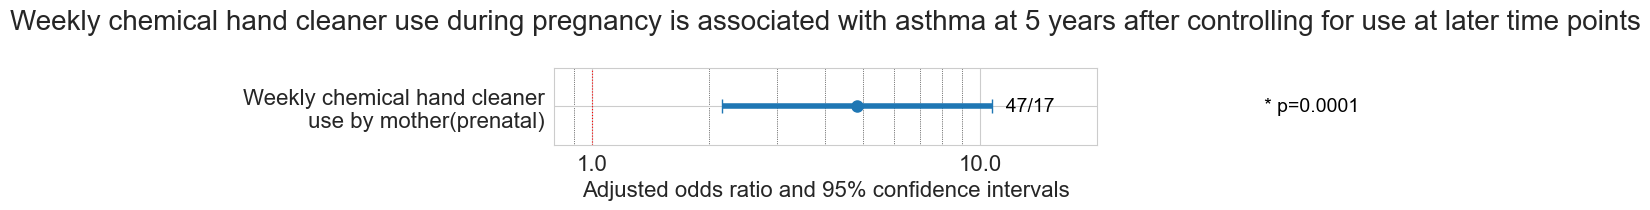

In [8]:
odds_ratio_table = odds_ratio_table.sort_values(by="exposure")


sns.set_style("whitegrid")
cfig, ax = plt.subplots(nrows=1, sharex=True, sharey=True, figsize=(7, 1))
plt.title("Weekly chemical hand cleaner use during pregnancy is associated with asthma at 5 years after controlling for use at later time points\n",fontsize=20)
for idx, row in odds_ratio_table.iloc[::-1].iterrows():
    if row['time outcome assessed']=='5 years':
        ci = [[row['OR'] - row['Lower CI']], [row['Upper CI'] - row['OR']]]
        if 1:
            label = str(row['OR'])
         
            plt.errorbar(x=[row['OR']], y=[row['exposure']], xerr=ci, ecolor='tab:blue', capsize=5, linestyle='None', linewidth=4, marker="o", markersize=8, mfc="tab:blue", mec="tab:blue")
       
            label = "  " +str(row['total exposures']-row['total cases with exposure']) + "/"+str(row['total cases with exposure'])+"                                       * p="+str(row['P-value'])
            # Add text to the right of the error bar
            plt.text(row['OR'] + ci[1][0] + 0.2, row['exposure'], f'{label}', color='black', va='center', fontsize=14)

plt.xscale('log',base=10)
# Apply the custom tick label formatting function
ax.xaxis.set_major_formatter(FuncFormatter(log_fmt))
ax.xaxis.grid(True, which='minor', linestyle=':', linewidth='0.5', color='black')
        
plt.axvline(x=1, linewidth=0.8, linestyle=':', color='red')
plt.tick_params(axis='both', which='major', labelsize=16)
plt.xlabel('Adjusted odds ratio and 95% confidence intervals', fontsize=16)

plt.xlim(0.8,20)

# Supplementary Figure 6b: iii. Frequency of prenatal chemical hand cleaner and association with asthma at 5 years after controlling for it's postnatal use

In [9]:
alternatedf = subjects.copy()
outcome = "asthma_5y"
visit = "5 Years"

odds_ratio_table = pd.DataFrame(columns=['time outcome assessed','outcome','exposure','total children','total cases','total exposures','total cases with exposure','OR','Lower CI', 'Upper CI','P-value'])

alternatedf = alternatedf[~alternatedf['frequency_of_use_of_chemical_hand_cleaner_prenatal'].isna()]
alternatedf = alternatedf[~alternatedf[outcome].isna()]
total_cases = alternatedf[alternatedf[outcome]==1]
total_cases_exposed = total_cases[total_cases["frequency_of_use_of_chemical_hand_cleaner_prenatal"]>=1]
total_exposures = alternatedf[alternatedf["frequency_of_use_of_chemical_hand_cleaner_prenatal"]>=1]
# Fit ANCOVA model with interaction term
model = sm.formula.logit('asthma_5y ~ frequency_of_use_of_chemical_hand_cleaner_prenatal + is_male + site_toronto + site_edmonton + site_vancouver + EBF_6m + vaginal_birth + total_household_income_PR18WK + older_children_in_home_3m + is_caucasian + num_antibiotic_courses_birth_to_1y + family_asthma_history + frequency_of_use_of_chemical_hand_cleaner_3m + frequency_of_use_of_chemical_hand_cleaner_1y', data=alternatedf).fit()

# Print model summary
print(model.summary())

odds_ratios = pd.DataFrame(
    {
        "OR": model.params,
        "Lower CI": model.conf_int()[0],
        "Upper CI": model.conf_int()[1]
    }
)
odds_ratios = np.exp(odds_ratios)

odds_ratios['P-value'] = round(model.pvalues,4)
odds_ratios[odds_ratios['P-value']<0.05]
odds_ratios['outcome']=outcome
odds_ratios['Lower CI'] = round(odds_ratios['Lower CI'],2)
odds_ratios['Upper CI'] = round(odds_ratios['Upper CI'],2)
odds_ratios['OR'] = round(odds_ratios['OR'],2)


odds_ratios = odds_ratios.loc["frequency_of_use_of_chemical_hand_cleaner_prenatal"]    


significant_effect_row = odds_ratios.to_dict()
                        
significant_effect_row['exposure']="Frequency of chemical hand cleaner\n use by mother(prenatal)"
significant_effect_row['time outcome assessed']="5 years"
significant_effect_row['total cases']=len(total_cases)
significant_effect_row['total exposures']=len(total_exposures)
significant_effect_row['total cases with exposure']=len(total_cases_exposed)
significant_effect_row['total children']=len(alternatedf)


odds_ratio_table.loc[len(odds_ratio_table)] = significant_effect_row


Optimization terminated successfully.
         Current function value: 0.236666
         Iterations 7
                           Logit Regression Results                           
Dep. Variable:              asthma_5y   No. Observations:                 1850
Model:                          Logit   Df Residuals:                     1835
Method:                           MLE   Df Model:                           14
Date:                Fri, 21 Nov 2025   Pseudo R-squ.:                 0.07955
Time:                        14:04:43   Log-Likelihood:                -437.83
converged:                       True   LL-Null:                       -475.67
Covariance Type:            nonrobust   LLR p-value:                 1.774e-10
                                                         coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------------------------------
Intercept                   

(0.8, 20)

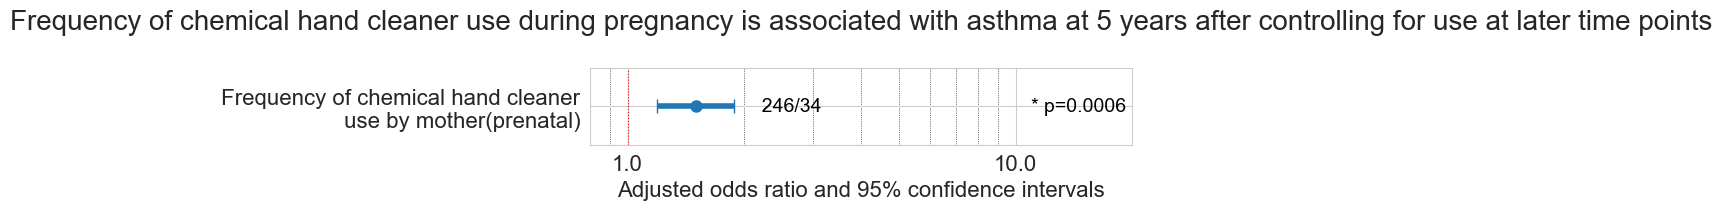

In [10]:
odds_ratio_table = odds_ratio_table.sort_values(by="exposure")


sns.set_style("whitegrid")
cfig, ax = plt.subplots(nrows=1, sharex=True, sharey=True, figsize=(7, 1))
plt.title("Frequency of chemical hand cleaner use during pregnancy is associated with asthma at 5 years after controlling for use at later time points\n",fontsize=20)
for idx, row in odds_ratio_table.iloc[::-1].iterrows():
    if row['time outcome assessed']=='5 years':
        ci = [[row['OR'] - row['Lower CI']], [row['Upper CI'] - row['OR']]]
        if 1:
            label = str(row['OR'])
         
            plt.errorbar(x=[row['OR']], y=[row['exposure']], xerr=ci, ecolor='tab:blue', capsize=5, linestyle='None', linewidth=4, marker="o", markersize=8, mfc="tab:blue", mec="tab:blue")
       
            label = "  " +str(row['total exposures']-row['total cases with exposure']) + "/"+str(row['total cases with exposure'])+"                                       * p="+str(row['P-value'])
            # Add text to the right of the error bar
            plt.text(row['OR'] + ci[1][0] + 0.2, row['exposure'], f'{label}', color='black', va='center', fontsize=14)

plt.xscale('log',base=10)
# Apply the custom tick label formatting function
ax.xaxis.set_major_formatter(FuncFormatter(log_fmt))
ax.xaxis.grid(True, which='minor', linestyle=':', linewidth='0.5', color='black')
        
plt.axvline(x=1, linewidth=0.8, linestyle=':', color='red')
plt.tick_params(axis='both', which='major', labelsize=16)
plt.xlabel('Adjusted odds ratio and 95% confidence intervals', fontsize=16)

plt.xlim(0.8,20)

In [12]:
#pd.set_option('precision',10)

# Supplementary Figure 6b: iv. Association between prenatal oven cleaner use and 5-year definite asthma after controlling for postnatal use

In [13]:
alternatedf = subjects.copy()
outcome = "asthma_5y"
visit = "5 Years"

odds_ratio_table = pd.DataFrame(columns=['time outcome assessed','outcome','exposure','total children','total cases','total exposures','total cases with exposure','OR','Lower CI', 'Upper CI','P-value'])

alternatedf = alternatedf[~alternatedf['weekly_oven_cleaner_use_mother_prenatal'].isna()]
alternatedf = alternatedf[~alternatedf[outcome].isna()]
total_cases = alternatedf[alternatedf[outcome]==1]
total_cases_exposed = total_cases[total_cases["weekly_oven_cleaner_use_mother_prenatal"]==1]
total_exposures = alternatedf[alternatedf["weekly_oven_cleaner_use_mother_prenatal"]==1]
# Fit ANCOVA model with interaction term
alternatedf = alternatedf.fillna(alternatedf.median())
#y=alternatedf[outcome]
#X = alternatedf[['weekly_oven_cleaner_use_mother_prenatal','is_male','site_toronto','site_edmonton','site_vancouver','EBF_6m','vaginal_birth','total_household_income_PR18WK','older_children_in_home_3m','is_caucasian','num_antibiotic_courses_birth_to_1y','family_asthma_history','prenatal_smoke_exposure','summer_birth','winter_birth','autumn_birth']]
#model = sm.Logit(y, X).fit(disp=0) # add disp=0 to turn off verbose output

model = sm.formula.logit('asthma_5y ~ weekly_oven_cleaner_use_mother_prenatal + is_male + site_toronto + site_edmonton + site_vancouver + EBF_6m + vaginal_birth + total_household_income_PR18WK + older_children_in_home_3m + is_caucasian  + num_antibiotic_courses_birth_to_1y + family_asthma_history + prenatal_smoke_exposure + summer_birth + winter_birth + autumn_birth + weekly_oven_cleaner_use_3m + weekly_oven_cleaner_use_3y + weekly_oven_cleaner_use_5y', data=alternatedf).fit()

# Print model summary
print(model.summary())

odds_ratios = pd.DataFrame(
    {
        "OR": model.params,
        "Lower CI": model.conf_int()[0],
        "Upper CI": model.conf_int()[1]
    }
)
odds_ratios = np.exp(odds_ratios)

odds_ratios['P-value'] = round(model.pvalues,4)
odds_ratios[odds_ratios['P-value']<0.05]
odds_ratios['outcome']=outcome
odds_ratios['Lower CI'] = round(odds_ratios['Lower CI'],2)
odds_ratios['Upper CI'] = round(odds_ratios['Upper CI'],2)
odds_ratios['OR'] = round(odds_ratios['OR'],2)


odds_ratios = odds_ratios.loc["weekly_oven_cleaner_use_mother_prenatal"]    


significant_effect_row = odds_ratios.to_dict()
                        
significant_effect_row['exposure']="Weekly oven cleaner use by mother (prenatal)"
significant_effect_row['time outcome assessed']="5 years"
significant_effect_row['total cases']=len(total_cases)
significant_effect_row['total exposures']=len(total_exposures)
significant_effect_row['total cases with exposure']=len(total_cases_exposed)
significant_effect_row['total children']=len(alternatedf)


odds_ratio_table.loc[len(odds_ratio_table)] = significant_effect_row

Optimization terminated successfully.
         Current function value: 0.227028
         Iterations 7
                           Logit Regression Results                           
Dep. Variable:              asthma_5y   No. Observations:                 2295
Model:                          Logit   Df Residuals:                     2275
Method:                           MLE   Df Model:                           19
Date:                Fri, 21 Nov 2025   Pseudo R-squ.:                 0.08591
Time:                        14:05:03   Log-Likelihood:                -521.03
converged:                       True   LL-Null:                       -570.00
Covariance Type:            nonrobust   LLR p-value:                 1.262e-12
                                              coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------------
Intercept                                  -3.3527

(0.8, 20)

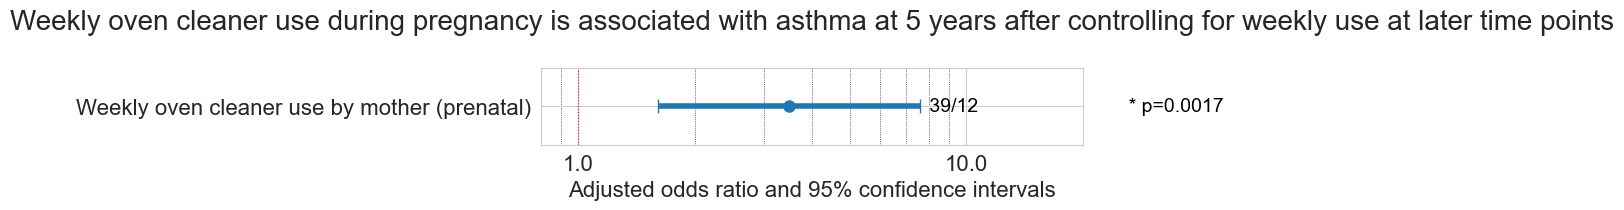

In [15]:
odds_ratio_table = odds_ratio_table.sort_values(by="exposure")


sns.set_style("whitegrid")
cfig, ax = plt.subplots(nrows=1, sharex=True, sharey=True, figsize=(7, 1))
plt.title("Weekly oven cleaner use during pregnancy is associated with asthma at 5 years after controlling for weekly use at later time points\n",fontsize=20)
for idx, row in odds_ratio_table.iloc[::-1].iterrows():
    if row['time outcome assessed']=='5 years':
        ci = [[row['OR'] - row['Lower CI']], [row['Upper CI'] - row['OR']]]
        if 1:
            label = str(row['OR'])
         
            plt.errorbar(x=[row['OR']], y=[row['exposure']], xerr=ci, ecolor='tab:blue', capsize=5, linestyle='None', linewidth=4, marker="o", markersize=8, mfc="tab:blue", mec="tab:blue")
       
            label = " "+str(row['total exposures']-row['total cases with exposure']) + "/"+str(row['total cases with exposure'])+"                            * p="+str(row['P-value'])
            # Add text to the right of the error bar
            plt.text(row['OR'] + ci[1][0] + 0.2, row['exposure'], f'{label}', color='black', va='center', fontsize=14)



plt.xscale('log',base=10)
# Apply the custom tick label formatting function
ax.xaxis.set_major_formatter(FuncFormatter(log_fmt))
ax.xaxis.grid(True, which='minor', linestyle=':', linewidth='0.5', color='black')
        
plt.axvline(x=1, linewidth=0.8, linestyle=':', color='red')
plt.tick_params(axis='both', which='major', labelsize=16)
plt.xlabel('Adjusted odds ratio and 95% confidence intervals', fontsize=16)

plt.xlim(0.8,20)

# Supplementary Figure 6b: i. Daily prenatal hand sanitizer association with 5-year asthma - control for daily postnatal hand sanitizer use

In [16]:
alternatedf = subjects.copy()
alternatedf.rename(columns={'frequency_of_use_of_purell-type_hand_cleaner_5Y':'frequency_of_use_of_purell_type_hand_cleaner_5Y','frequency_of_use_of_purell-type_hand_cleaner_prenatal':'frequency_of_use_of_purell_type_hand_cleaner_prenatal'}, inplace=True)
alternatedf.rename(columns={'frequency_of_use_of_purell-type_hand_cleaner_5Y':'frequency_of_use_of_purell_type_hand_cleaner_5Y','frequency_of_use_of_purell-type_hand_cleaner_1Y':'frequency_of_use_of_purell_type_hand_cleaner_1Y','frequency_of_use_of_purell-type_hand_cleaner_3m':'frequency_of_use_of_purell_type_hand_cleaner_3m','frequency_of_use_of_purell-type_hand_cleaner_3Y':'frequency_of_use_of_purell_type_hand_cleaner_3Y'}, inplace=True)


odds_ratio_table = pd.DataFrame(columns=['time outcome assessed','outcome','exposure','total children','total cases','total exposures','total cases with exposure','OR','Lower CI', 'Upper CI','P-value'])
outcome = "asthma_5y"
visit = "5 Years"
# Fit ANCOVA model with interaction term
model = sm.formula.logit('asthma_5y ~ daily_hand_sanitizer_used_prenatal + is_male + site_toronto + site_edmonton + site_vancouver + EBF_6m + vaginal_birth + total_household_income_PR18WK + older_children_in_home_3m + is_caucasian + num_antibiotic_courses_birth_to_1y + family_asthma_history + frequency_of_use_of_purell_type_hand_cleaner_3m + frequency_of_use_of_purell_type_hand_cleaner_1Y + frequency_of_use_of_purell_type_hand_cleaner_3Y + frequency_of_use_of_purell_type_hand_cleaner_5Y', data=alternatedf).fit()

total_cases = alternatedf[alternatedf[outcome]==1]
total_cases_exposed = total_cases[total_cases["daily_hand_sanitizer_used_prenatal"]!=0]
total_exposures = alternatedf[alternatedf["daily_hand_sanitizer_used_prenatal"]!=0]

# Print model summary
print(model.summary())


odds_ratios = pd.DataFrame(
    {
        "OR": model.params,
        "Lower CI": model.conf_int()[0],
        "Upper CI": model.conf_int()[1]
    }
)
odds_ratios = np.exp(odds_ratios)

odds_ratios['P-value'] = round(model.pvalues,4)
odds_ratios[odds_ratios['P-value']<0.05]
odds_ratios['outcome']=outcome
odds_ratios['Lower CI'] = round(odds_ratios['Lower CI'],2)
odds_ratios['Upper CI'] = round(odds_ratios['Upper CI'],2)
odds_ratios['OR'] = round(odds_ratios['OR'],2)


odds_ratios = odds_ratios.loc["daily_hand_sanitizer_used_prenatal"]    


significant_effect_row = odds_ratios.to_dict()
                        
significant_effect_row['exposure']="Daily use of hand sanitizer by mother (prenatal)"
significant_effect_row['time outcome assessed']="5 years"
significant_effect_row['total cases']=len(total_cases)
significant_effect_row['total exposures']=len(total_exposures)
significant_effect_row['total cases with exposure']=len(total_cases_exposed)
significant_effect_row['total children']=len(alternatedf)


odds_ratio_table.loc[len(odds_ratio_table)] = significant_effect_row


Optimization terminated successfully.
         Current function value: 0.213714
         Iterations 8
                           Logit Regression Results                           
Dep. Variable:              asthma_5y   No. Observations:                 1428
Model:                          Logit   Df Residuals:                     1411
Method:                           MLE   Df Model:                           16
Date:                Fri, 21 Nov 2025   Pseudo R-squ.:                  0.1195
Time:                        14:05:28   Log-Likelihood:                -305.18
converged:                       True   LL-Null:                       -346.59
Covariance Type:            nonrobust   LLR p-value:                 5.182e-11
                                                      coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------------------------
Intercept                         

In [17]:
odds_ratios = pd.DataFrame(
                            {
                                "OR": model.params,
                                "Lower CI": model.conf_int()[0],
                                "Upper CI": model.conf_int()[1]
                            }
                        )
odds_ratios = np.exp(odds_ratios)

odds_ratios['P-value'] = round(model.pvalues,4)
odds_ratios[odds_ratios['P-value']<0.05]
odds_ratios['Lower CI'] = round(odds_ratios['Lower CI'],2)
odds_ratios['Upper CI'] = round(odds_ratios['Upper CI'],2)
odds_ratios['OR'] = round(odds_ratios['OR'],2)
odds_ratios

,OR,Lower CI,Upper CI,P-value
Intercept,0.04,0.01,0.12,0.0000
daily_hand_sanitizer_used_prenatal,2.43,1.38,4.27,0.0021
is_male,1.77,1.12,2.81,0.0147
site_toronto,1.61,0.86,3.01,0.1404
site_edmonton,1.30,0.69,2.47,0.4202
site_vancouver,1.45,0.78,2.69,0.2444
EBF_6m,0.65,0.34,1.25,0.1954
vaginal_birth,0.64,0.40,1.03,0.0656
total_household_income_PR18WK,0.95,0.84,1.07,0.4058
older_children_in_home_3m,0.92,0.59,1.44,0.7288


(0.8, 20)

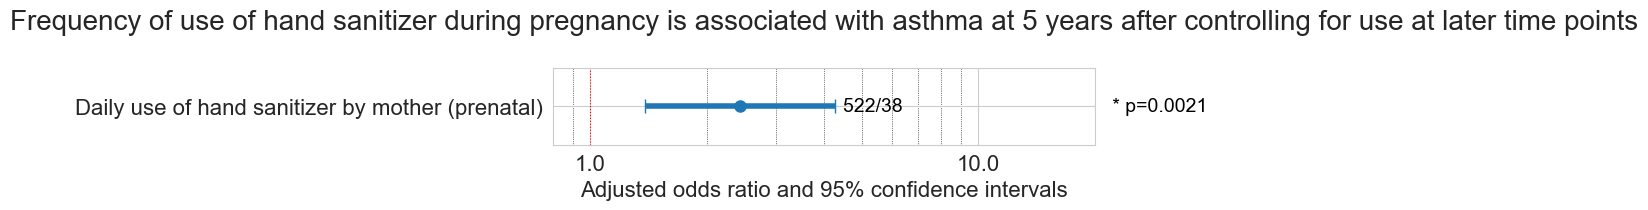

In [18]:
odds_ratio_table = odds_ratio_table.sort_values(by="exposure")


sns.set_style("whitegrid")
cfig, ax = plt.subplots(nrows=1, sharex=True, sharey=True, figsize=(7, 1))
plt.title("Frequency of use of hand sanitizer during pregnancy is associated with asthma at 5 years after controlling for use at later time points\n",fontsize=20)
for idx, row in odds_ratio_table.iloc[::-1].iterrows():
    if row['time outcome assessed']=='5 years':
        ci = [[row['OR'] - row['Lower CI']], [row['Upper CI'] - row['OR']]]
        if 1:
            label = str(row['OR'])
         
            plt.errorbar(x=[row['OR']], y=[row['exposure']], xerr=ci, ecolor='tab:blue', capsize=5, linestyle='None', linewidth=4, marker="o", markersize=8, mfc="tab:blue", mec="tab:blue")
       
            label = str(row['total exposures']-row['total cases with exposure']) + "/"+str(row['total cases with exposure'])+"                                       * p="+str(row['P-value'])
            # Add text to the right of the error bar
            plt.text(row['OR'] + ci[1][0] + 0.2, row['exposure'], f'{label}', color='black', va='center', fontsize=14)



plt.xscale('log',base=10)
# Apply the custom tick label formatting function
ax.xaxis.set_major_formatter(FuncFormatter(log_fmt))
ax.xaxis.grid(True, which='minor', linestyle=':', linewidth='0.5', color='black')
        
plt.axvline(x=1, linewidth=0.8, linestyle=':', color='red')
plt.tick_params(axis='both', which='major', labelsize=16)
plt.xlabel('Adjusted odds ratio and 95% confidence intervals', fontsize=16)

plt.xlim(0.8,20)

# Supplementary figure 6a

- Associations betweeen weekly oven cleaner use, weekly chemical hand cleaner use, daily hand sanitizer use and odds of developing 5-year definite asthma

- Controlling for their combined effects (and including weekly tile cleaner use)

In [20]:
alternatedf = subjects.copy()
outcome = "asthma_5y"
visit = "5 Years"

odds_ratio_table = pd.DataFrame(columns=['time outcome assessed','outcome','exposure','total children','total cases','total exposures','total cases with exposure','OR','Lower CI', 'Upper CI','P-value'])
outcome = "asthma_5y"
visit = "5 Years"




alternatedf = alternatedf[~alternatedf['daily_hand_sanitizer_used_prenatal'].isna()]

alternatedf = alternatedf[~alternatedf[outcome].isna()]
total_cases = alternatedf[alternatedf[outcome]==1]

# Fit ANCOVA model with interaction term
#model = sm.formula.logit('asthma_5y ~ weekly_oven_cleaner_use_mother_prenatal + weekly_chem_hand_cleaner_use_mother_prenatal + is_male +  EBF_6m + vaginal_birth + total_household_income_PR18WK + older_children_in_home_3m + is_caucasian + num_antibiotic_courses_birth_to_1y + family_asthma_history', data=alternatedf).fit()
model = sm.formula.logit('asthma_5y ~ weekly_oven_cleaner_use_mother_prenatal + weekly_tile_cleaner_use_prenatal + weekly_chem_hand_cleaner_use_mother_prenatal + daily_hand_sanitizer_used_prenatal', data=alternatedf).fit()
# Print model summary
print(model.summary())





for col in ['daily_hand_sanitizer_used_prenatal','weekly_oven_cleaner_use_mother_prenatal','weekly_chem_hand_cleaner_use_mother_prenatal']:



    total_cases_exposed = total_cases[total_cases[col]==1]
    total_exposures = alternatedf[alternatedf[col]==1]


    odds_ratios = pd.DataFrame(
    {
        "OR": model.params,
        "Lower CI": model.conf_int()[0],
        "Upper CI": model.conf_int()[1]
    }
)

    odds_ratios = np.exp(odds_ratios)

    #odds_ratios['P-value'] = round(model.pvalues,4)

    odds_ratios['P-value'] = model.pvalues
    odds_ratios[odds_ratios['P-value']<0.05]
    odds_ratios['outcome']=outcome
    odds_ratios['Lower CI'] = round(odds_ratios['Lower CI'],2)
    odds_ratios['Upper CI'] = round(odds_ratios['Upper CI'],2)
    odds_ratios['OR'] = round(odds_ratios['OR'],2)




    odds_ratios = odds_ratios.loc[col]    


    significant_effect_row = odds_ratios.to_dict()
                            
    significant_effect_row['exposure']=col
    significant_effect_row['time outcome assessed']="5 years"
    significant_effect_row['total cases']=len(total_cases)
    significant_effect_row['total exposures']=len(total_exposures)
    significant_effect_row['total cases with exposure']=len(total_cases_exposed)
    significant_effect_row['total children']=len(alternatedf)


    odds_ratio_table.loc[len(odds_ratio_table)] = significant_effect_row

Optimization terminated successfully.
         Current function value: 0.239790
         Iterations 7
                           Logit Regression Results                           
Dep. Variable:              asthma_5y   No. Observations:                 2294
Model:                          Logit   Df Residuals:                     2289
Method:                           MLE   Df Model:                            4
Date:                Fri, 21 Nov 2025   Pseudo R-squ.:                 0.03483
Time:                        14:05:45   Log-Likelihood:                -550.08
converged:                       True   LL-Null:                       -569.93
Covariance Type:            nonrobust   LLR p-value:                 4.985e-08
                                                   coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------------------------
Intercept                               

In [21]:
odds_ratio_table

,time outcome assessed,outcome,exposure,total children,total cases,total exposures,total cases with exposure,OR,Lower CI,Upper CI,P-value
0,5 years,asthma_5y,daily_hand_sanitizer_used_prenatal,2389,164,360,37,1.65,1.11,2.45,0.013116
1,5 years,asthma_5y,weekly_oven_cleaner_use_mother_prenatal,2389,164,51,12,2.63,1.25,5.53,0.010696
2,5 years,asthma_5y,weekly_chem_hand_cleaner_use_mother_prenatal,2389,164,64,17,4.00,2.13,7.49,0.000015


(0.8, 20)

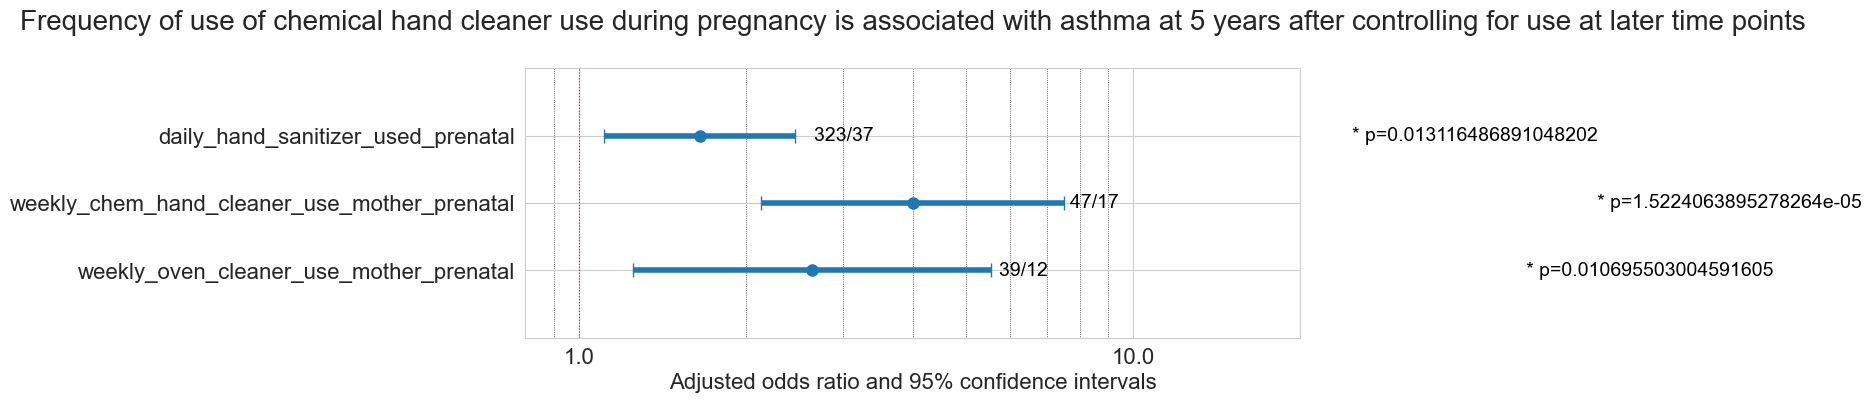

In [22]:
odds_ratio_table = odds_ratio_table.sort_values(by="exposure")


sns.set_style("whitegrid")
cfig, ax = plt.subplots(nrows=1, sharex=True, sharey=True, figsize=(10, 3.5))
plt.title("Frequency of use of chemical hand cleaner use during pregnancy is associated with asthma at 5 years after controlling for use at later time points\n",fontsize=20)
for idx, row in odds_ratio_table.iloc[::-1].iterrows():
    if row['time outcome assessed']=='5 years':
        ci = [[row['OR'] - row['Lower CI']], [row['Upper CI'] - row['OR']]]
        if 1:
            label = str(row['OR'])
         
            plt.errorbar(x=[row['OR']], y=[row['exposure']], xerr=ci, ecolor='tab:blue', capsize=5, linestyle='None', linewidth=4, marker="o", markersize=8, mfc="tab:blue", mec="tab:blue")
       
            label = str(row['total exposures']-row['total cases with exposure']) + "/"+str(row['total cases with exposure'])+"                                                                                         * p="+str(row['P-value'])
            # Add text to the right of the error bar
            plt.text(row['OR'] + ci[1][0] + 0.2, row['exposure'], f'{label}', color='black', va='center', fontsize=14)



plt.xscale('log',base=10)
# Apply the custom tick label formatting function
ax.xaxis.set_major_formatter(FuncFormatter(log_fmt))
ax.xaxis.grid(True, which='minor', linestyle=':', linewidth='0.5', color='black')
        
plt.axvline(x=1, linewidth=0.8, linestyle=':', color='red')
plt.tick_params(axis='both', which='major', labelsize=16)
plt.xlabel('Adjusted odds ratio and 95% confidence intervals', fontsize=16)
ax.set_ylim(-1, 3)
plt.xlim(0.8,20)